# Demonic and Protective Entities in the Book of the Dead
 A Computational Demonology Using NLP and Named Entity Recognition
# Research Question:
 1. How are demonic and protective supernatural agents distributed across?
 2. Book of the Dead spells, and what computational patterns reveal about?
 3. their roles in ancient Egyptian funerary belief?


In [1]:
import os


data_folder = "Downloads/book_of_dead_texts"

# Load all chapter files
chapters = {}

for filename in os.listdir(data_folder):
    if filename.endswith(".txt"):
        filepath = os.path.join(data_folder, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()
        chapters[filename] = text


print(f"Total chapters loaded: {len(chapters)}")
print()

for name, text in sorted(chapters.items()):
    word_count = len(text.split())
    print(f"{name}: {word_count} words")

Total chapters loaded: 16

chapter1.txt: 118 words
chapter11_12.txt: 1234 words
chapter13.txt: 520 words
chapter2.txt: 82 words
chapter3.txt: 214 words
chapter4.txt: 178 words
chapter5_6.txt: 140 words
chapter7_10.txt: 33 words
chapter_14.txt: 529 words
chapter_15.txt: 1352 words
chapter_16.txt: 1464 words
chapter_17.txt: 1003 words
chapter_18.txt: 616 words
chapter_19.txt: 882 words
chapter_20.txt: 114 words
chapter_21.txt: 410 words


In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

# Split each chapter into sentences
all_sentences = []

for filename, text in sorted(chapters.items()):
    sentences = sent_tokenize(text)
    for sentence in sentences:
        all_sentences.append({
            "chapter": filename,
            "sentence": sentence.strip()
        })

# Print summary
print(f"Total sentences: {len(all_sentences)}")
print()

# Show first 5 sentences as a sample
print("Sample sentences:")
for item in all_sentences[:5]:
    print(f"\n[{item['chapter']}]")
    print(item['sentence'])

Total sentences: 478

Sample sentences:

[chapter1.txt]
A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE EASTERN PART OF HEAVEN.

[chapter1.txt]
Behold Osiris Ani the scribe who recordeth the holy offerings of all the gods, (2) who saith: "Homage to thee, O thou who hast come as Khepera,[2] Khepera, the creator of the gods.

[chapter1.txt]
Thou risest, thou shinest, (3) making bright thy mother [Nut], crowned king of the gods.

[chapter1.txt]
[Thy] mother Nut doeth homage unto thee with both her hands.

[chapter1.txt]
(4) The land of Manu[4] receiveth thee with content, and the goddess Maat[5] embraceth thee at the two seasons.


[nltk_data] Downloading package punkt to /Users/juhi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/juhi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
import re

def clean_sentence(text):
    # Remove line numbers like (2), (3), (14)
    text = re.sub(r'\(\d+\)', '', text)
    # Remove footnote references like [2], [14]
    text = re.sub(r'\[\d+\]', '', text)
    # Remove multiple spaces left behind
    text = re.sub(r' +', ' ', text)
    # Strip leading/trailing whitespace
    text = text.strip()
    return text

# Apply cleaning to all sentences
for item in all_sentences:
    item['sentence'] = clean_sentence(item['sentence'])

# Remove very short sentences (less than 5 words)
all_sentences = [item for item in all_sentences 
                 if len(item['sentence'].split()) >= 5]


print(f"Total sentences after cleaning: {len(all_sentences)}")
print()


print("Sample cleaned sentences:")
for item in all_sentences[:5]:
    print(f"\n[{item['chapter']}]")
    print(item['sentence'])

Total sentences after cleaning: 407

Sample cleaned sentences:

[chapter1.txt]
A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE EASTERN PART OF HEAVEN.

[chapter1.txt]
Behold Osiris Ani the scribe who recordeth the holy offerings of all the gods, who saith: "Homage to thee, O thou who hast come as Khepera, Khepera, the creator of the gods.

[chapter1.txt]
Thou risest, thou shinest, making bright thy mother [Nut], crowned king of the gods.

[chapter1.txt]
[Thy] mother Nut doeth homage unto thee with both her hands.

[chapter1.txt]
The land of Manu receiveth thee with content, and the goddess Maat embraceth thee at the two seasons.


In [4]:
def clean_sentence_v2(text):
    # Remove line numbers like (2), (3), (14)
    text = re.sub(r'\(\d+\)', '', text)
    # Remove footnote references like [2], [14]
    text = re.sub(r'\[\d+\]', '', text)
    # Remove brackets but keep the word inside like [Nut] → Nut
    text = re.sub(r'\[([^\]]+)\]', r'\1', text)
    # Remove multiple spaces
    text = re.sub(r' +', ' ', text)
    # Strip
    text = text.strip()
    return text

for item in all_sentences:
    item['sentence'] = clean_sentence_v2(item['sentence'])


print("Sample sentences after v2 cleaning:")
for item in all_sentences[:5]:
    print(f"\n[{item['chapter']}]")
    print(item['sentence'])

Sample sentences after v2 cleaning:

[chapter1.txt]
A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE EASTERN PART OF HEAVEN.

[chapter1.txt]
Behold Osiris Ani the scribe who recordeth the holy offerings of all the gods, who saith: "Homage to thee, O thou who hast come as Khepera, Khepera, the creator of the gods.

[chapter1.txt]
Thou risest, thou shinest, making bright thy mother Nut, crowned king of the gods.

[chapter1.txt]
Thy mother Nut doeth homage unto thee with both her hands.

[chapter1.txt]
The land of Manu receiveth thee with content, and the goddess Maat embraceth thee at the two seasons.


In [5]:
import json

# Save all cleaned sentences to a JSON file
output_path = "Downloads/annotated/sentences_clean.json"

# Make sure the folder exists
os.makedirs("Downloads/annotated", exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(all_sentences, f, indent=2, ensure_ascii=False)

print(f"Saved {len(all_sentences)} sentences to {output_path}")

Saved 407 sentences to Downloads/annotated/sentences_clean.json


In [6]:
import subprocess
subprocess.run(["pip", "install", "spacy"])
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 19.1 MB/s  0:00:00 20.6 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [7]:
import spacy

# Load spaCy's pre-trained English model
nlp = spacy.load("en_core_web_sm")

# Run NER on all sentences and collect unique entities
found_entities = {}

for item in all_sentences:
    doc = nlp(item['sentence'])
    for ent in doc.ents:
        entity_text = ent.text.strip()
        spacy_label = ent.label_
        
        if entity_text not in found_entities:
            found_entities[entity_text] = spacy_label

# Print what spaCy found
print(f"Total unique entities found: {len(found_entities)}")
print()

for entity, label in sorted(found_entities.items()):
    print(f"{entity:30s} → {label}")

Total unique entities found: 195

1 am                           → QUANTITY
1 am Horus                     → TIME
261                            → CARDINAL
3                              → CARDINAL
ANI                            → ORG
Abtu                           → GPE
Akert                          → PERSON
Amenta                         → WORK_OF_ART
Amentet                        → GPE
Ani                            → PERSON
Annu                           → ORG
Antes                          → GPE
Anubis                         → ORG
Apep                           → PERSON
Apuat                          → PERSON
Ari-su-tchesef                 → PERSON
Arit                           → ORG
Assembler of Souls'            → WORK_OF_ART
Astennu                        → ORG
Ates-hra                       → PERSON
Atet                           → PERSON
Bebi                           → PERSON
Behold                         → PERSON
CHAPTER OF GIVING BREATH IN    → ORG
EASTERN            

In [8]:
# Our corrected entity dictionary built from spaCy's findings
entity_dict = {
    "DEITY": [
        "Osiris", "Ra", "Thoth", "Horus", "Isis", "Nephthys", "Anubis",
        "Nut", "Maat", "Shu", "Tefnut", "Seb", "Ptah", "Khepera",
        "Tmu", "Hathor", "Sekhet", "Apuat", "Bebi", "Astennu",
        "Ptah-Seker-Tem", "Un-nefer", "Tmu-Khepera", "Tmu-Heru-khuti",
        "Neb-er-tcher", "Nehebka", "Heru-khuti", "Sabsabu", "Merti",
        "Mestha", "Hapi", "Seker", "Nebt-Unnet"
    ],
    "DEMON": [
        "Apep", "Set", "Sebau", "Fiend", "the Evil One",
        "the Enemy", "the Destroyer", "the Crocodile",
        "the Fighter", "Am-mit", "Tchatcha", "Rehui", "Bebi"
    ],
    "LOCATION": [
        "Amenta", "Amentet", "Annu", "Tattu", "Re-stau", "Sekhem",
        "Neter-khert", "Sekhet-Aaru", "Sekhet-hetepu", "Abtu",
        "Pe", "Tep", "Naarutef", "Naarerutf", "Ta-sertet", "Akert",
        "Unnu", "Manu", "Memphis", "Nile", "An-rut-f", "Suten-henen",
        "Mesqen", "Arit", "Duat", "Abydos", "Kher-aba", "Nekhen",
        "the Lake of Fire", "the Lake of Flowers", "the Lake of Horus",
        "the House of Hearts", "the Great Balance", "the Hall of Two Truths",
        "the Field of Reeds"
    ],
    "OBJECT": [
        "utchat", "urerit crown", "scarab", "crook", "flail",
        "sektet boat", "atet boat", "matet boat", "scales", "balance",
        "the Egg of the Great Cackler"
    ],
    "RITUAL": [
        "weighing of the heart", "opening of the mouth",
        "coming forth by day", "judgment"
    ],
    "ROLE": [
        "Osiris Ani", "the scribe", "the deceased", "the doorkeeper",
        "the watcher", "the herald", "the guardian", "the scribe Ani"
    ]
}

# Print summary
print("Entity dictionary summary:")
print()
for category, entities in entity_dict.items():
    print(f"{category}: {len(entities)} entities")

print(f"\nTotal entities: {sum(len(v) for v in entity_dict.values())}")

Entity dictionary summary:

DEITY: 33 entities
DEMON: 13 entities
LOCATION: 35 entities
OBJECT: 11 entities
RITUAL: 4 entities
ROLE: 8 entities

Total entities: 104


In [9]:
def annotate_sentence(sentence, entity_dict):
    """
    Find all entities in a sentence using our dictionary.
    Returns a list of (entity_text, label, start, end) tuples.
    """
    annotations = []
    sentence_lower = sentence.lower()
    
    for label, entities in entity_dict.items():
        for entity in entities:
            entity_lower = entity.lower()
            # Find all occurrences of this entity in the sentence
            start = 0
            while True:
                pos = sentence_lower.find(entity_lower, start)
                if pos == -1:
                    break
                end = pos + len(entity)
                annotations.append({
                    "entity": sentence[pos:end],
                    "label": label,
                    "start": pos,
                    "end": end
                })
                start = pos + 1
    
    # Sort by position in sentence
    annotations.sort(key=lambda x: x["start"])
    return annotations

# Annotate all sentences
annotated_data = []

for item in all_sentences:
    annotations = annotate_sentence(item["sentence"], entity_dict)
    annotated_data.append({
        "chapter": item["chapter"],
        "sentence": item["sentence"],
        "annotations": annotations
    })

# Count statistics
total_annotations = sum(len(item["annotations"]) for item in annotated_data)
sentences_with_entities = sum(1 for item in annotated_data 
                               if len(item["annotations"]) > 0)

print(f"Total annotations found: {total_annotations}")
print(f"Sentences with at least one entity: {sentences_with_entities}")
print(f"Sentences with no entities: {len(annotated_data) - sentences_with_entities}")
print()

# Show 3 annotated examples
print("Sample annotated sentences:")
count = 0
for item in annotated_data:
    if len(item["annotations"]) >= 2:
        print(f"\n[{item['chapter']}]")
        print(f"Sentence: {item['sentence']}")
        print(f"Entities found:")
        for ann in item["annotations"]:
            print(f"  → [{ann['entity']}] = {ann['label']}")
        count += 1
    if count == 3:
        break

Total annotations found: 813
Sentences with at least one entity: 287
Sentences with no entities: 120

Sample annotated sentences:

[chapter1.txt]
Sentence: A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE EASTERN PART OF HEAVEN.
Entities found:
  → [RA] = DEITY
  → [RA] = DEITY
  → [SET] = DEMON

[chapter1.txt]
Sentence: Behold Osiris Ani the scribe who recordeth the holy offerings of all the gods, who saith: "Homage to thee, O thou who hast come as Khepera, Khepera, the creator of the gods.
Entities found:
  → [Osiris] = DEITY
  → [Osiris Ani] = ROLE
  → [the scribe] = ROLE
  → [Khepera] = DEITY
  → [pe] = LOCATION
  → [ra] = DEITY
  → [Khepera] = DEITY
  → [pe] = LOCATION
  → [ra] = DEITY

[chapter1.txt]
Sentence: The land of Manu receiveth thee with content, and the goddess Maat embraceth thee at the two seasons.
Entities found:
  → [Manu] = LOCATION
  → [Maat] = DEITY
  → [ra] = DEITY


In [10]:
def annotate_sentence_v2(sentence, entity_dict):
    """
    Improved annotation using whole-word matching.
    """
    annotations = []
    
    for label, entities in entity_dict.items():
        # Sort by length descending so longer entities match first
        # e.g. "Osiris Ani" matches before "Osiris"
        sorted_entities = sorted(entities, key=len, reverse=True)
        
        for entity in sorted_entities:
            # Use regex word boundary for whole word matching
            pattern = r'\b' + re.escape(entity) + r'\b'
            for match in re.finditer(pattern, sentence, re.IGNORECASE):
                annotations.append({
                    "entity": sentence[match.start():match.end()],
                    "label": label,
                    "start": match.start(),
                    "end": match.end()
                })
    
    # Remove overlapping annotations — keep the longest match
    annotations.sort(key=lambda x: (x["start"], -(x["end"] - x["start"])))
    filtered = []
    last_end = -1
    for ann in annotations:
        if ann["start"] >= last_end:
            filtered.append(ann)
            last_end = ann["end"]
    
    return filtered

# Re-annotate all sentences with improved function
annotated_data = []

for item in all_sentences:
    annotations = annotate_sentence_v2(item["sentence"], entity_dict)
    annotated_data.append({
        "chapter": item["chapter"],
        "sentence": item["sentence"],
        "annotations": annotations
    })

# Count statistics
total_annotations = sum(len(item["annotations"]) for item in annotated_data)
sentences_with_entities = sum(1 for item in annotated_data 
                               if len(item["annotations"]) > 0)

print(f"Total annotations found: {total_annotations}")
print(f"Sentences with at least one entity: {sentences_with_entities}")
print(f"Sentences with no entities: {len(annotated_data) - sentences_with_entities}")
print()

# Show 3 examples
print("Sample annotated sentences:")
count = 0
for item in annotated_data:
    if len(item["annotations"]) >= 2:
        print(f"\n[{item['chapter']}]")
        print(f"Sentence: {item['sentence']}")
        print(f"Entities found:")
        for ann in item["annotations"]:
            print(f"  → [{ann['entity']}] = {ann['label']}")
        count += 1
    if count == 3:
        break

Total annotations found: 527
Sentences with at least one entity: 255
Sentences with no entities: 152

Sample annotated sentences:

[chapter1.txt]
Sentence: Behold Osiris Ani the scribe who recordeth the holy offerings of all the gods, who saith: "Homage to thee, O thou who hast come as Khepera, Khepera, the creator of the gods.
Entities found:
  → [Osiris Ani] = ROLE
  → [the scribe] = ROLE
  → [Khepera] = DEITY
  → [Khepera] = DEITY

[chapter1.txt]
Sentence: The land of Manu receiveth thee with content, and the goddess Maat embraceth thee at the two seasons.
Entities found:
  → [Manu] = LOCATION
  → [Maat] = DEITY

[chapter11_12.txt]
Sentence: The name of the doorkeeper is Sekhet-hra-asht-aru; the name of the watcher is Meti-heh (?
Entities found:
  → [the doorkeeper] = ROLE
  → [Sekhet] = DEITY
  → [the watcher] = ROLE


In [11]:
# Save annotated data to JSON
output_path = "Downloads/annotated/annotated_sentences.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(annotated_data, f, indent=2, ensure_ascii=False)

print(f"Saved {len(annotated_data)} annotated sentences to {output_path}")
print()

# Print entity label distribution
from collections import Counter

label_counts = Counter()
for item in annotated_data:
    for ann in item["annotations"]:
        label_counts[ann["label"]] += 1

print("Entity label distribution:")
for label, count in label_counts.most_common():
    print(f"  {label:12s}: {count}")

Saved 407 annotated sentences to Downloads/annotated/annotated_sentences.json

Entity label distribution:
  DEITY       : 257
  ROLE        : 128
  LOCATION    : 90
  DEMON       : 23
  OBJECT      : 16
  RITUAL      : 13


In [12]:
# Convert to spaCy training format
def convert_to_spacy_format(annotated_data):
    spacy_data = []
    
    for item in annotated_data:
        sentence = item["sentence"]
        entities = []
        
        for ann in item["annotations"]:
            entities.append((ann["start"], ann["end"], ann["label"]))
        
        if entities:  # Only include sentences that have at least one entity
            spacy_data.append((sentence, {"entities": entities}))
    
    return spacy_data

spacy_training_data = convert_to_spacy_format(annotated_data)

print(f"Training examples: {len(spacy_training_data)}")
print()

# Show 2 examples in spaCy format
print("Sample spaCy format:")
for text, annotations in spacy_training_data[:2]:
    print(f"\nText: {text}")
    print(f"Entities: {annotations['entities']}")

Training examples: 255

Sample spaCy format:

Text: A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE EASTERN PART OF HEAVEN.
Entities: [(20, 22, 'DEITY')]

Text: Behold Osiris Ani the scribe who recordeth the holy offerings of all the gods, who saith: "Homage to thee, O thou who hast come as Khepera, Khepera, the creator of the gods.
Entities: [(7, 17, 'ROLE'), (18, 28, 'ROLE'), (131, 138, 'DEITY'), (140, 147, 'DEITY')]


In [13]:
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
import random

# Create a blank English spaCy model
nlp_ner = spacy.blank("en")

# Add NER pipeline
ner = nlp_ner.add_pipe("ner")

# Add all our entity labels
for label in entity_dict.keys():
    ner.add_label(label)

# Training setup
optimizer = nlp_ner.begin_training()

print("Starting training...")
print()

# Train for 30 iterations
losses_history = []

for iteration in range(30):
    random.shuffle(spacy_training_data)
    losses = {}
    
    # Create batches
    batches = minibatch(spacy_training_data, size=compounding(4.0, 32.0, 1.001))
    
    for batch in batches:
        examples = []
        for text, annotations in batch:
            doc = nlp_ner.make_doc(text)
            example = Example.from_dict(doc, annotations)
            examples.append(example)
        
        nlp_ner.update(examples, drop=0.3, losses=losses)
    
    losses_history.append(losses["ner"])
    
    if (iteration + 1) % 5 == 0:
        print(f"Iteration {iteration + 1}/30 — Loss: {losses['ner']:.4f}")

print()
print("Training complete!")

Starting training...

Iteration 5/30 — Loss: 195.6810
Iteration 10/30 — Loss: 94.7332
Iteration 15/30 — Loss: 43.0221
Iteration 20/30 — Loss: 17.6701
Iteration 25/30 — Loss: 24.6891
Iteration 30/30 — Loss: 25.8747

Training complete!


In [14]:
# Pick random sentences from your actual corpus to test on
random.seed(42)
test_samples = random.sample(annotated_data, 10)

print("Model predictions on real corpus sentences:")
print()

for item in test_samples:
    sentence = item["sentence"]
    
    # What our dictionary found (ground truth)
    ground_truth = [(ann["entity"], ann["label"]) 
                    for ann in item["annotations"]]
    
    # What the model predicts
    doc = nlp_ner(sentence)
    predictions = [(ent.text, ent.label_) for ent in doc.ents]
    
    print(f"Sentence: {sentence}")
    print(f"  Ground truth : {ground_truth}")
    print(f"  Model predict: {predictions}")
    print()

Model predictions on real corpus sentences:

Sentence: I am the Moon among the gods; I shall not come to an end.
  Ground truth : []
  Model predict: []

Sentence: Saith Osiris, the scribe Ani, triumphant: "Lo, the lady of light, the mighty one, to whom men cry aloud; man knoweth neither her breadth nor her height; there was never found her like from the beginning (?).
  Ground truth : [('Osiris', 'DEITY'), ('the scribe Ani', 'ROLE')]
  Model predict: [('Osiris', 'DEITY'), ('the scribe Ani', 'ROLE')]

Sentence: The name of the doorkeeper is Un-hat; the name of the watcher is Seqet-hra; the name of the herald is Uset.
  Ground truth : [('the doorkeeper', 'ROLE'), ('the watcher', 'ROLE'), ('the herald', 'ROLE')]
  Model predict: [('the doorkeeper', 'ROLE'), ('the watcher', 'ROLE'), ('the herald', 'ROLE')]

Sentence: Homage to thee, O An in Antes, Horus, thou dweller in both horizons, with long strides thou stridest over heaven, O thou who dwellest in both horizons.
  Ground truth : [('Ho

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract all DEITY and DEMON entities from annotations
deity_counts = Counter()
demon_counts = Counter()

for item in annotated_data:
    for ann in item["annotations"]:
        if ann["label"] == "DEITY":
            deity_counts[ann["entity"]] += 1
        elif ann["label"] == "DEMON":
            demon_counts[ann["entity"]] += 1

# Print raw counts first
print("TOP DEITIES:")
for name, count in deity_counts.most_common(10):
    print(f"  {name:20s}: {count}")

print()
print("TOP DEMONS:")
for name, count in demon_counts.most_common(10):
    print(f"  {name:20s}: {count}")

TOP DEITIES:
  Osiris              : 101
  Ra                  : 27
  Horus               : 25
  Thoth               : 20
  Nut                 : 12
  Isis                : 7
  Tmu                 : 6
  Shu                 : 6
  OSIRIS              : 5
  Anubis              : 5

TOP DEMONS:
  Set                 : 11
  set                 : 4
  Tchatcha            : 2
  Fiend               : 2
  Rehui               : 1
  Apep                : 1
  Sebau               : 1
  the Fighter         : 1


In [16]:
# Fix case inconsistency by normalizing entity names
deity_counts_clean = Counter()
demon_counts_clean = Counter()

for item in annotated_data:
    for ann in item["annotations"]:
        # Normalize to title case e.g. OSIRIS → Osiris, set → Set
        entity_name = ann["entity"].strip().title()
        
        if ann["label"] == "DEITY":
            deity_counts_clean[entity_name] += 1
        elif ann["label"] == "DEMON":
            demon_counts_clean[entity_name] += 1

# Print cleaned counts
print("TOP DEITIES (cleaned):")
for name, count in deity_counts_clean.most_common(10):
    print(f"  {name:20s}: {count}")

print()
print("TOP DEMONS (cleaned):")
for name, count in demon_counts_clean.most_common(10):
    print(f"  {name:20s}: {count}")

TOP DEITIES (cleaned):
  Osiris              : 106
  Ra                  : 30
  Horus               : 25
  Thoth               : 20
  Nut                 : 12
  Isis                : 7
  Tmu                 : 6
  Shu                 : 6
  Anubis              : 5
  Khepera             : 4

TOP DEMONS (cleaned):
  Set                 : 15
  Tchatcha            : 2
  Fiend               : 2
  Rehui               : 1
  Apep                : 1
  Sebau               : 1
  The Fighter         : 1


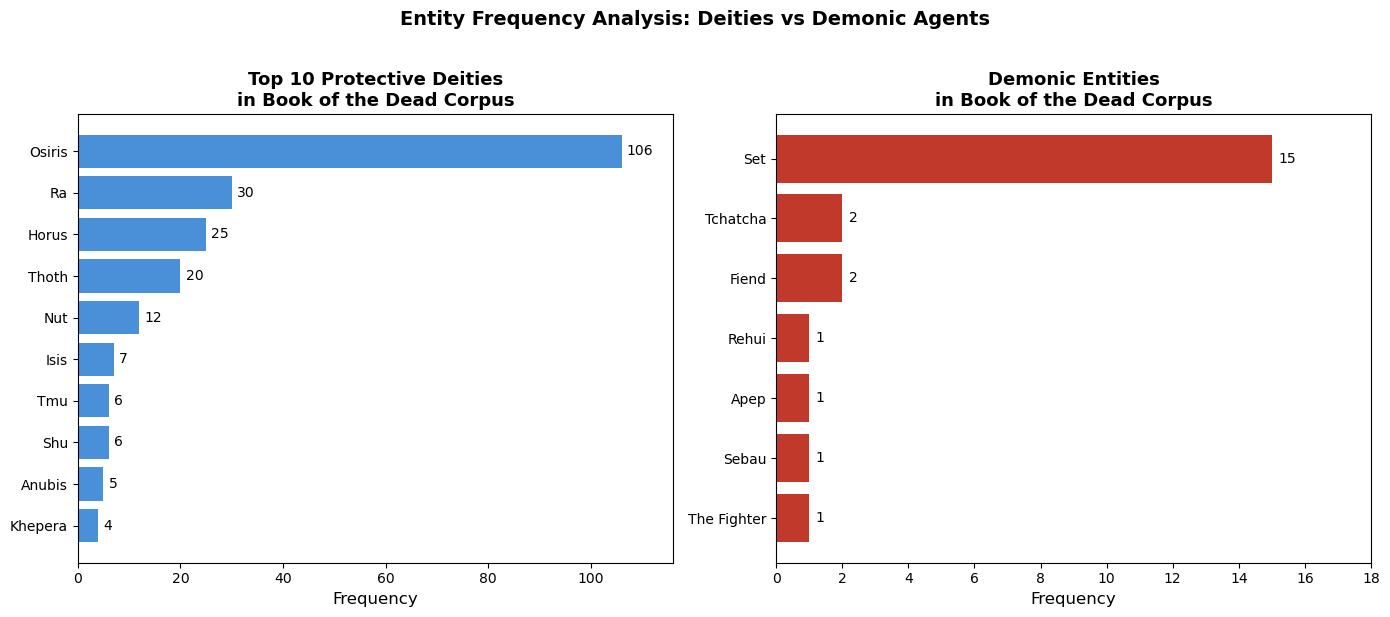

Saved visualization 1!


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Top Deities ---
top_deities = deity_counts_clean.most_common(10)
deity_names = [x[0] for x in top_deities]
deity_values = [x[1] for x in top_deities]

bars1 = ax1.barh(deity_names[::-1], deity_values[::-1], color="#4A90D9")
ax1.set_xlabel("Frequency", fontsize=12)
ax1.set_title("Top 10 Protective Deities\nin Book of the Dead Corpus", 
              fontsize=13, fontweight="bold")
ax1.set_xlim(0, max(deity_values) + 10)

# Add value labels
for bar, val in zip(bars1, deity_values[::-1]):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, 
             str(val), va="center", fontsize=10)

# --- Plot 2: Demons ---
top_demons = demon_counts_clean.most_common(10)
demon_names = [x[0] for x in top_demons]
demon_values = [x[1] for x in top_demons]

bars2 = ax2.barh(demon_names[::-1], demon_values[::-1], color="#C0392B")
ax2.set_xlabel("Frequency", fontsize=12)
ax2.set_title("Demonic Entities\nin Book of the Dead Corpus", 
              fontsize=13, fontweight="bold")
ax2.set_xlim(0, max(demon_values) + 3)

# Add value labels
for bar, val in zip(bars2, demon_values[::-1]):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2, 
             str(val), va="center", fontsize=10)

plt.suptitle("Entity Frequency Analysis: Deities vs Demonic Agents", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("Downloads/deity_demon_frequency.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved visualization 1!")

In [18]:
import subprocess
subprocess.run(["pip", "install", "networkx"])

CompletedProcess(args=['pip', 'install', 'networkx'], returncode=0)

In [19]:
import networkx as nx

# Build co-occurrence network
# Two entities co-occur if they appear in the same sentence
G = nx.Graph()

for item in annotated_data:
    # Get all deities and demons in this sentence
    entities_in_sentence = []
    for ann in item["annotations"]:
        if ann["label"] in ["DEITY", "DEMON"]:
            entity_name = ann["entity"].strip().title()
            label = ann["label"]
            entities_in_sentence.append((entity_name, label))
    
    # Add nodes
    for entity_name, label in entities_in_sentence:
        if not G.has_node(entity_name):
            G.add_node(entity_name, label=label)
    
    # Add edges between every pair in the same sentence
    for i in range(len(entities_in_sentence)):
        for j in range(i+1, len(entities_in_sentence)):
            e1 = entities_in_sentence[i][0]
            e2 = entities_in_sentence[j][0]
            if G.has_edge(e1, e2):
                G[e1][e2]["weight"] += 1
            else:
                G.add_edge(e1, e2, weight=1)

print(f"Network nodes: {G.number_of_nodes()}")
print(f"Network edges: {G.number_of_edges()}")
print()

# Show strongest co-occurrences
print("Strongest co-occurrences (deity-demon pairs):")
edges = [(u, v, d["weight"]) for u, v, d in G.edges(data=True)]
edges_sorted = sorted(edges, key=lambda x: x[2], reverse=True)

for u, v, w in edges_sorted[:15]:
    u_label = G.nodes[u].get("label", "")
    v_label = G.nodes[v].get("label", "")
    if "DEMON" in [u_label, v_label]:
        print(f"  {u:15s} ({u_label:6s}) ↔ {v:15s} ({v_label:6s}) : {w} sentences")

Network nodes: 37
Network edges: 81

Strongest co-occurrences (deity-demon pairs):
  Tmu             (DEITY ) ↔ Set             (DEMON ) : 3 sentences


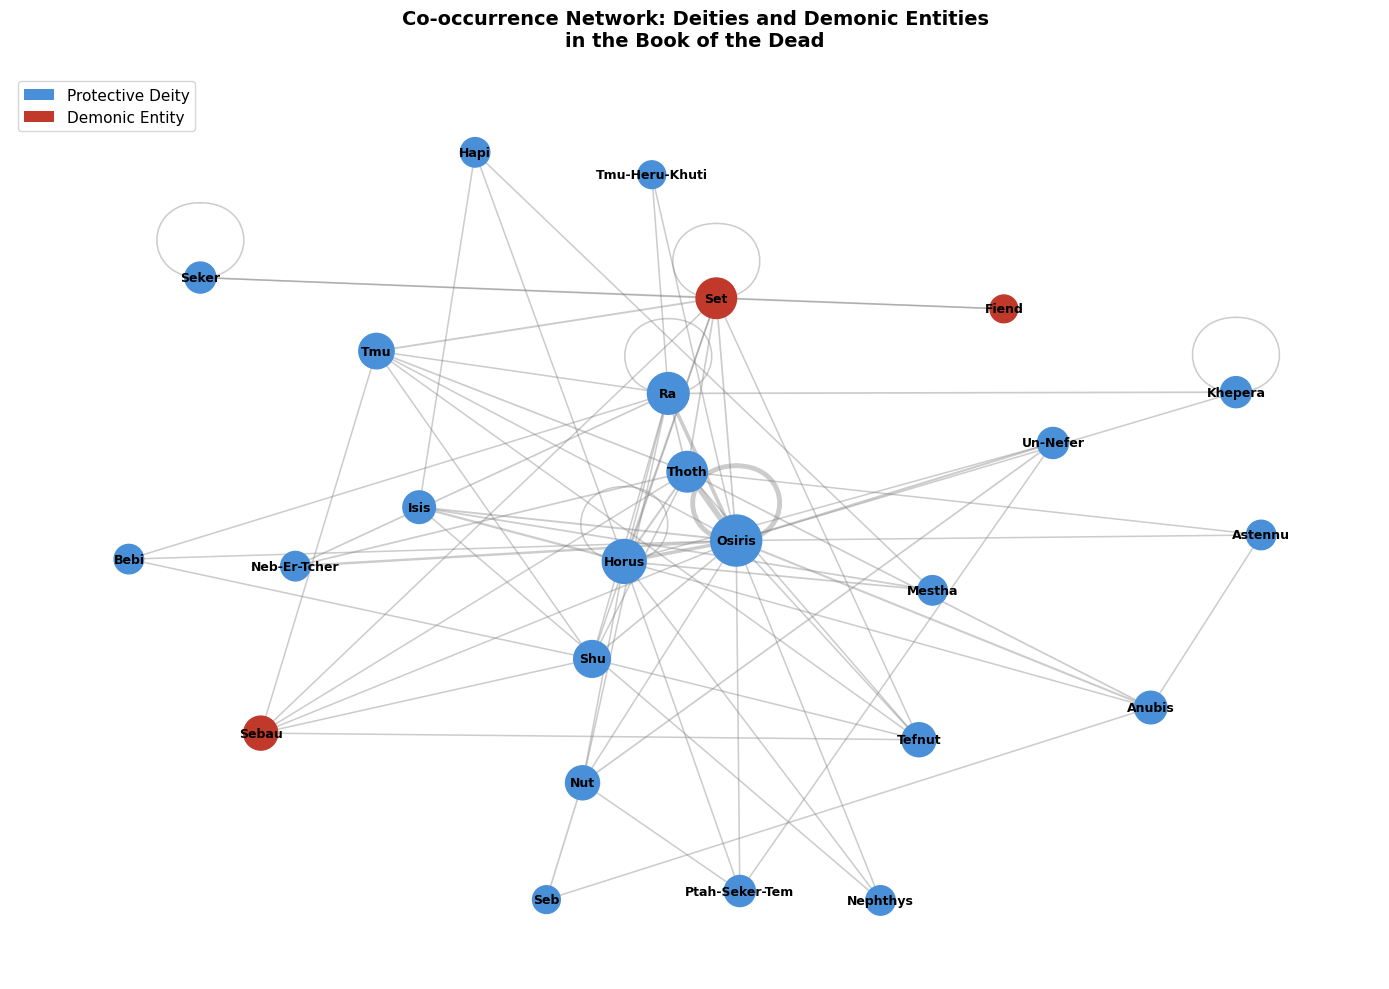

Saved visualization 2!


In [20]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Separate nodes by type for coloring
deity_nodes = [n for n, d in G.nodes(data=True) if d.get("label") == "DEITY"]
demon_nodes = [n for n, d in G.nodes(data=True) if d.get("label") == "DEMON"]

# Filter to only show nodes with at least 2 connections for clarity
significant_nodes = [n for n in G.nodes() if G.degree(n) >= 2]
G_filtered = G.subgraph(significant_nodes)

deity_nodes_f = [n for n in G_filtered.nodes() 
                 if G.nodes[n].get("label") == "DEITY"]
demon_nodes_f = [n for n in G_filtered.nodes() 
                 if G.nodes[n].get("label") == "DEMON"]

# Layout
pos = nx.spring_layout(G_filtered, seed=42, k=2)

# Edge weights for thickness
edges = G_filtered.edges(data=True)
edge_weights = [d["weight"] for u, v, d in edges]
max_weight = max(edge_weights) if edge_weights else 1

# Draw edges
nx.draw_networkx_edges(G_filtered, pos, 
                       width=[1 + 3 * (w/max_weight) for w in edge_weights],
                       alpha=0.4, edge_color="gray", ax=ax)

# Draw deity nodes
nx.draw_networkx_nodes(G_filtered, pos, 
                       nodelist=deity_nodes_f,
                       node_color="#4A90D9",
                       node_size=[300 + 50 * G_filtered.degree(n) 
                                  for n in deity_nodes_f],
                       ax=ax)

# Draw demon nodes
nx.draw_networkx_nodes(G_filtered, pos,
                       nodelist=demon_nodes_f,
                       node_color="#C0392B",
                       node_size=[300 + 50 * G_filtered.degree(n) 
                                  for n in demon_nodes_f],
                       ax=ax)

# Labels
nx.draw_networkx_labels(G_filtered, pos, 
                        font_size=9, font_weight="bold", ax=ax)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4A90D9", label="Protective Deity"),
    Patch(facecolor="#C0392B", label="Demonic Entity")
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11)

ax.set_title("Co-occurrence Network: Deities and Demonic Entities\nin the Book of the Dead",
             fontsize=14, fontweight="bold", pad=20)
ax.axis("off")

plt.tight_layout()
plt.savefig("Downloads/cooccurrence_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved visualization 2!")

In [21]:
# Analyze demon and deity distribution across chapters
chapter_stats = {}

for item in annotated_data:
    chapter = item["chapter"]
    if chapter not in chapter_stats:
        chapter_stats[chapter] = {"DEITY": 0, "DEMON": 0, "total": 0}
    
    for ann in item["annotations"]:
        if ann["label"] == "DEITY":
            chapter_stats[chapter]["DEITY"] += 1
        elif ann["label"] == "DEMON":
            chapter_stats[chapter]["DEMON"] += 1
        chapter_stats[chapter]["total"] += 1

# Clean up chapter names for display
def clean_chapter_name(filename):
    name = filename.replace(".txt", "")
    name = name.replace("chapter_", "Chapter ")
    name = name.replace("chapter", "Chapter ")
    return name.strip().title()

# Sort by demon count
sorted_chapters = sorted(chapter_stats.items(), 
                         key=lambda x: x[1]["DEMON"], 
                         reverse=True)

# Print table
print(f"{'Chapter':20s} {'Deities':>8s} {'Demons':>8s} {'Ratio':>10s}")
print("-" * 50)
for chapter, stats in sorted_chapters:
    name = clean_chapter_name(chapter)
    deities = stats["DEITY"]
    demons = stats["DEMON"]
    ratio = f"{deities}:{demons}" if demons > 0 else f"{deities}:0"
    print(f"{name:20s} {deities:>8d} {demons:>8d} {ratio:>10s}")

Chapter               Deities   Demons      Ratio
--------------------------------------------------
Chapter 16                 27        5       27:5
Chapter 13                 42        4       42:4
Chapter 19                 23        4       23:4
Chapter 15                 23        3       23:3
Chapter 11_12              26        2       26:2
Chapter 3                   4        1        4:1
Chapter 14                 38        1       38:1
Chapter 17                 21        1       21:1
Chapter 18                 19        1       19:1
Chapter 20                  1        1        1:1
Chapter 1                   7        0        7:0
Chapter 2                   4        0        4:0
Chapter 4                   7        0        7:0
Chapter 5_6                 2        0        2:0
Chapter 7_10                0        0        0:0
Chapter 21                 13        0       13:0


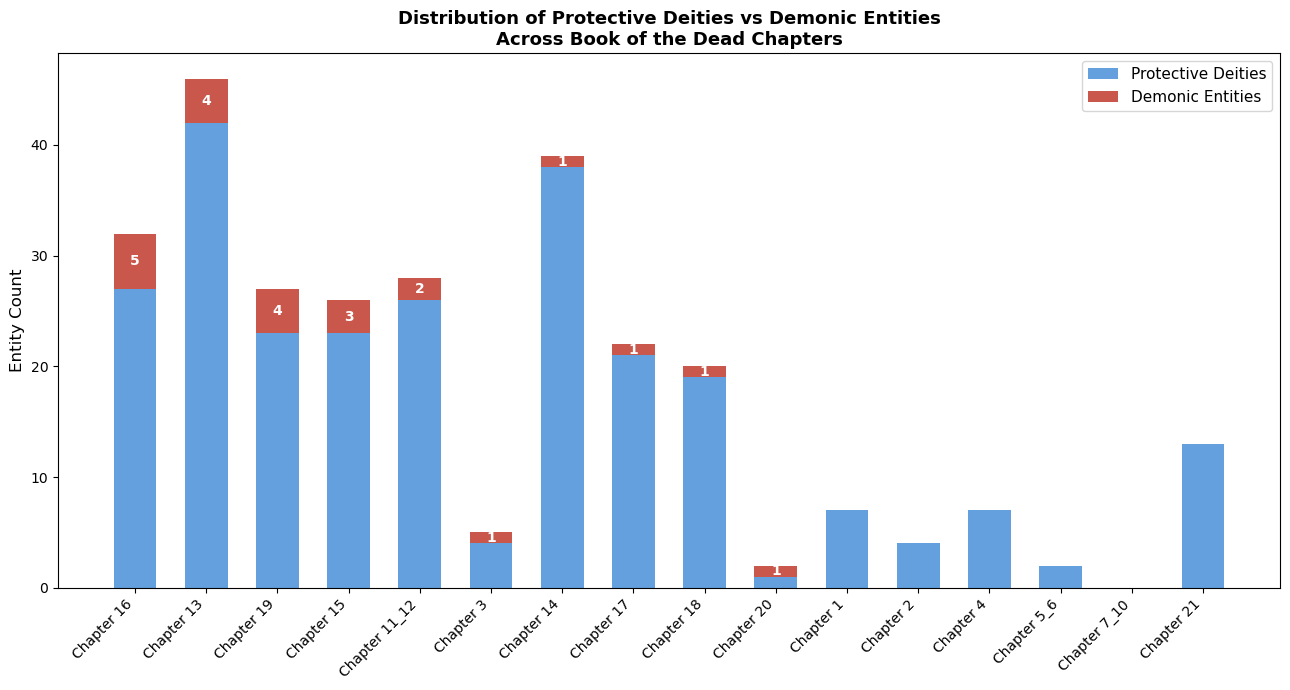

Saved visualization 3!


In [22]:
fig, ax = plt.subplots(figsize=(13, 7))

# Prepare data
chapter_names = [clean_chapter_name(ch) for ch, _ in sorted_chapters]
deity_values = [stats["DEITY"] for _, stats in sorted_chapters]
demon_values = [stats["DEMON"] for _, stats in sorted_chapters]

x = range(len(chapter_names))
width = 0.6

# Stacked bars
bars1 = ax.bar(x, deity_values, width, label="Protective Deities", 
               color="#4A90D9", alpha=0.85)
bars2 = ax.bar(x, demon_values, width, bottom=deity_values,
               label="Demonic Entities", color="#C0392B", alpha=0.85)

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(chapter_names, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Entity Count", fontsize=12)
ax.set_title("Distribution of Protective Deities vs Demonic Entities\nAcross Book of the Dead Chapters",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)

# Add demon count labels on red bars
for bar, demon_val in zip(bars2, demon_values):
    if demon_val > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_y() + bar.get_height()/2,
                str(demon_val),
                ha="center", va="center",
                color="white", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig("Downloads/chapter_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved visualization 3!")